# Data Augmentation

In [26]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
import random
import yaml
from PIL import Image

### Carga de datos almacenados

In [27]:
# Cargamos el dataframe desde el .CSV y definimos 'id' como índice
try:
    df = pd.read_csv('dataframe_splitted.csv').set_index('id')
except FileNotFoundError:
    print(f"Error: El archivo 'dataframe.csv' no se encontró en la ubicación actual: {os.getcwd()}")
    print("Se creará nuevamente al correr las celdas de 'Importación de imágenes'.")
    df = None
except Exception as e:
    print(f"Ocurrió un error al leer el archivo CSV: {e}")
    df = None

In [28]:
# Cargar variables desde el archivo YAML
try:
    # Verificar si el archivo YAML existe
    yaml_filename = "constants.yaml"
    with open(yaml_filename, "r") as yaml_file:
        constants_data = yaml.safe_load(yaml_file)

    # Acceder a las variables
    ROOT_DIR = constants_data.get("ROOT_DIR")
    DATASET_PATH = constants_data.get("DATASET_PATH")
    SPLITTED_PATH = constants_data.get("SPLITTED_PATH")

    print(f"✅ Se han cargado las variables de configuración desde '{yaml_filename}'")
    print(f" - ROOT_DIR: {ROOT_DIR}")
    print(f" - DATASET_PATH: {DATASET_PATH}")
    print(f" - SPLITTED_PATH: {SPLITTED_PATH}")
except FileNotFoundError:
    print(f"Error: El archivo 'constants.yaml' no se encontró en la ubicación actual: {os.getcwd()}")
    print("Se creará nuevamente al correr el notebook.")
    ROOT_DIR = None
    DATASET_PATH = None
    SPLITTED_PATH = None
except Exception as e:
    print(f"Ocurrió un error al leer el archivo YAML: {e}")

✅ Se han cargado las variables de configuración desde 'constants.yaml'
 - ROOT_DIR: /Users/alejandrolloveras/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3/plantvillage dataset/color
 - DATASET_PATH: /Users/alejandrolloveras/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3
 - SPLITTED_PATH: /Users/alejandrolloveras/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/splitted/


In [29]:
# Carga de imagenes en memoria y visualización
def load_image(data: pd.DataFrame, index: int, root: str=ROOT_DIR):
    """
    Carga una imagen PIL desde una fila específica de un DataFrame.

    Args:
        dataframe (pandas.DataFrame): El DataFrame que contiene las rutas de las imágenes.
        index (int): El índice de la fila en el DataFrame para cargar la imagen.
        root_dir (str): El directorio raíz donde se encuentran las imágenes.

    Returns:
        PIL.Image.Image: La imagen cargada como un objeto PIL.Image, o None si ocurre un error.
    """
    if index < 0 or index >= len(data):
        print("Índice fuera de rango.")
        return None

    row = data.iloc[index]
    relative_path = row['image_path']
    filename = row['filename']
    full_path = os.path.join(root, relative_path, filename)

    try:
        img = Image.open(full_path)
        return img
    except FileNotFoundError:
        print(f"Archivo no encontrado: {full_path}")
        return None
    except Exception as e:
        print(f"Error al cargar la imagen: {e}")
        return None

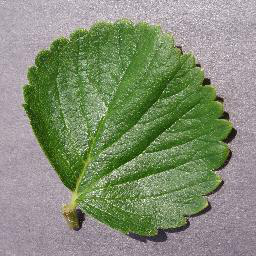

In [30]:
# Permite visualizar una imagen específica (con iloc)
id = 0 # Indice de la imagen a cargar
image = load_image(data=df, index=id, root=ROOT_DIR)

#image.show() #popup option
image

# Augmentation

In [46]:
# 1. Define las transformaciones de Albumentations
transform = A.Compose([
    A.Rotate(limit=180, p=0.5),          # Rotación aleatoria hasta 180 grados con probabilidad 0.5
    A.HorizontalFlip(p=0.5),            # Volteo horizontal con probabilidad 0.5
    A.VerticalFlip(p=0.5),              # Volteo vertical con probabilidad 0.5
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3), # Ajuste de brillo y contraste aleatorio
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.3), # Ajuste de tono, saturación y valor
    A.RandomCrop(width=200, height=200, p=0.3), # Recorte aleatorio a 200x200
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),   # Desenfoque Gaussiano
    A.RandomScale(scale_limit=0.1, p=0.3),      # Escalado aleatorio con un límite de 10%
])

In [47]:
"""
TRANSFORMACIONES ALBUMENTATION:
    A.Rotate(limit=180, p=0.5),          # Rotación aleatoria hasta 180 grados con probabilidad 0.5
    A.HorizontalFlip(p=0.5),            # Volteo horizontal con probabilidad 0.5
    A.VerticalFlip(p=0.5),              # Volteo vertical con probabilidad 0.5
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3), # Ajuste de brillo y contraste aleatorio
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.3), # Ajuste de tono, saturación y valor
    A.RandomCrop(width=200, height=200, p=0.3), # Recorte aleatorio a 200x200
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),   # Desenfoque Gaussiano
    A.RandomScale(scale_limit=0.1, p=0.3),      # Escalado aleatorio con un límite de 10%
    A.AdditiveNoise(p=0.2), # Ruido aditivo
    A.CLAHE(clip_limit=2.0, p=0.3),             # Ecualización CLAHE
    A.Resize(height=256, width=256, p=1),      # Redimensionamiento a 256x256
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), p=1), # Normalización
    A.AdvancedBlur(blur_limit=(3, 7), p=0.2), # Desenfoque avanzado
    A.RandomGridShuffle(grid=(2, 2), p=0.3), # Mezcla de rejilla aleatoria
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3), # Ajuste de brillo y contraste aleatorio
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.3), # Ajuste de tono, saturación y valor
"""

'\nTRANSFORMACIONES ALBUMENTATION:\n    A.Rotate(limit=180, p=0.5),          # Rotación aleatoria hasta 180 grados con probabilidad 0.5\n    A.HorizontalFlip(p=0.5),            # Volteo horizontal con probabilidad 0.5\n    A.VerticalFlip(p=0.5),              # Volteo vertical con probabilidad 0.5\n    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3), # Ajuste de brillo y contraste aleatorio\n    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.3), # Ajuste de tono, saturación y valor\n    A.RandomCrop(width=200, height=200, p=0.3), # Recorte aleatorio a 200x200\n    A.GaussianBlur(blur_limit=(3, 5), p=0.2),   # Desenfoque Gaussiano\n    A.RandomScale(scale_limit=0.1, p=0.3),      # Escalado aleatorio con un límite de 10%\n    A.AdditiveNoise(p=0.2), # Ruido aditivo\n    A.CLAHE(clip_limit=2.0, p=0.3),             # Ecualización CLAHE\n    A.Resize(height=256, width=256, p=1),      # Redimensionamiento a 256x256\n    A.Norma

Visualizando imágenes originales y transformadas (5 muestras):
Muestra #1 (Índice: 8222):


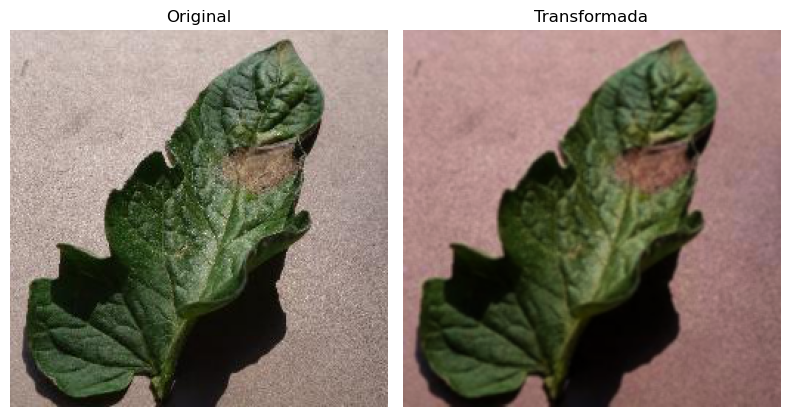

Muestra #2 (Índice: 51908):


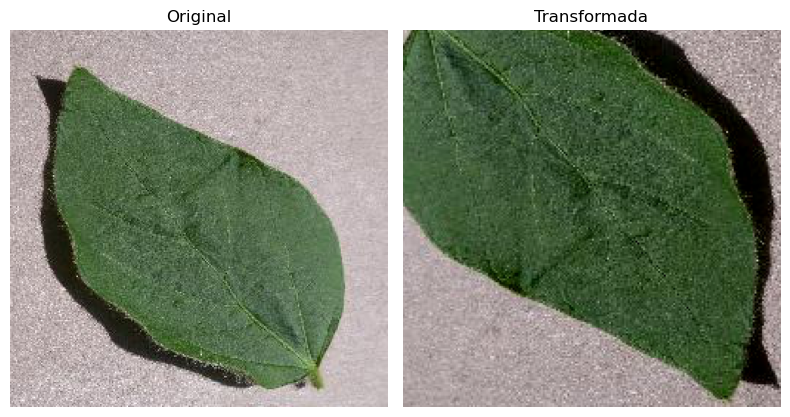

Muestra #3 (Índice: 28904):


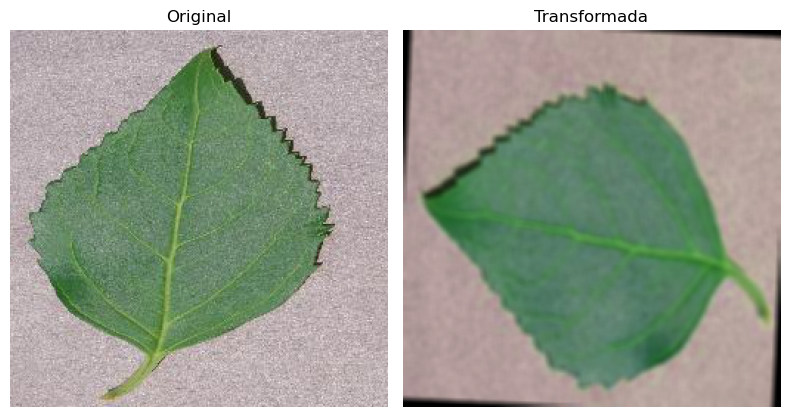

Muestra #4 (Índice: 40582):


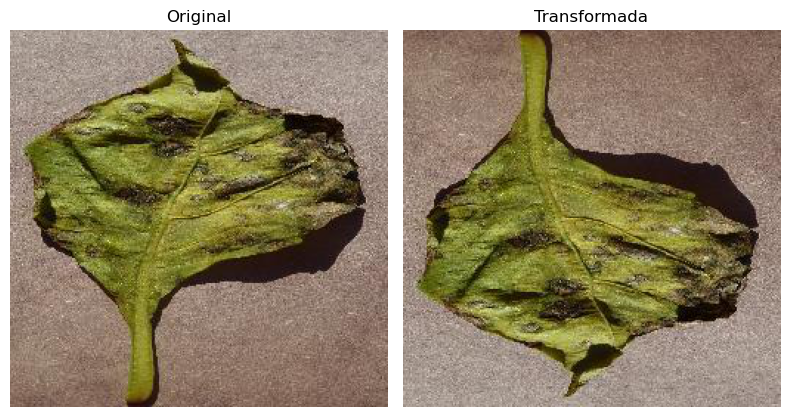

Muestra #5 (Índice: 12731):


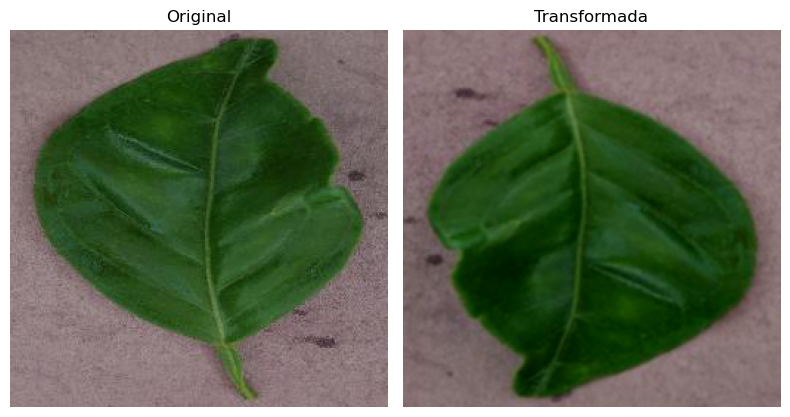

In [48]:
num_to_display = 5  # Reducir para mejor visualización en el gráfico
random_indices = random.sample(range(len(df)), num_to_display)

print(f"Visualizando imágenes originales y transformadas ({num_to_display} muestras):")
for i, index in enumerate(random_indices):
    try:
        original_image = load_image(data=df, index=index, root=ROOT_DIR)
        print(f"Muestra #{i+1} (Índice: {index}):")

        # Convertir la imagen original a un array NumPy para la transformación
        original_image_array = np.array(original_image)

        # Aplicar las transformaciones
        transformed = transform(image=original_image_array)
        transformed_image_array = transformed['image']

        fig, axes = plt.subplots(1, 2, figsize=(8, 5))

        # Mostrar la imagen original en el primer subplot (izquierda)
        axes[0].imshow(original_image_array)
        axes[0].set_title('Original')
        axes[0].axis('off')  # Ocultar los ejes

        # Mostrar la imagen transformada en el segundo subplot (derecha)
        axes[1].imshow(transformed_image_array)
        axes[1].set_title('Transformada')
        axes[1].axis('off')  # Ocultar los ejes

        plt.tight_layout()  # Ajustar el espaciado entre subplots para evitar superposiciones
        plt.show()

    except FileNotFoundError:
        print(f"Error: No se encontró la imagen en la ruta: {os.path.join(ROOT_DIR, df.loc[index, 'relative_path'])}")
    except Exception as e:
        print(f"Error al cargar la imagen en el índice {index}: {e}")